In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

train_df = pd.read_csv('artifacts/train.csv')
print("Train set shape for EDA:", train_df.shape)

print("\n--- Data Info ---")
train_df.info()

missing_values = train_df.isnull().sum()
print("\n--- Missing Values per Column ---")
print(missing_values[missing_values > 0])

Train set shape for EDA: (69608, 19)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69608 entries, 0 to 69607
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       69608 non-null  object 
 1   customer_id                    69608 non-null  object 
 2   order_status                   69608 non-null  object 
 3   order_purchase_timestamp       69608 non-null  object 
 4   order_approved_at              69484 non-null  object 
 5   order_delivered_carrier_date   68346 non-null  object 
 6   order_delivered_customer_date  67511 non-null  object 
 7   order_estimated_delivery_date  69608 non-null  object 
 8   customer_unique_id             69608 non-null  object 
 9   customer_zip_code_prefix       69608 non-null  int64  
 10  customer_city                  69608 non-null  object 
 11  customer_state                 69608 non-null  obj

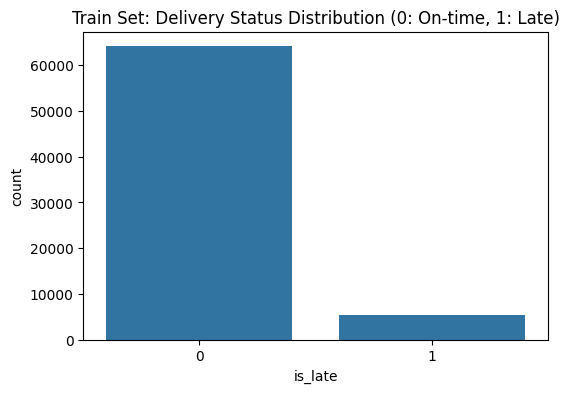

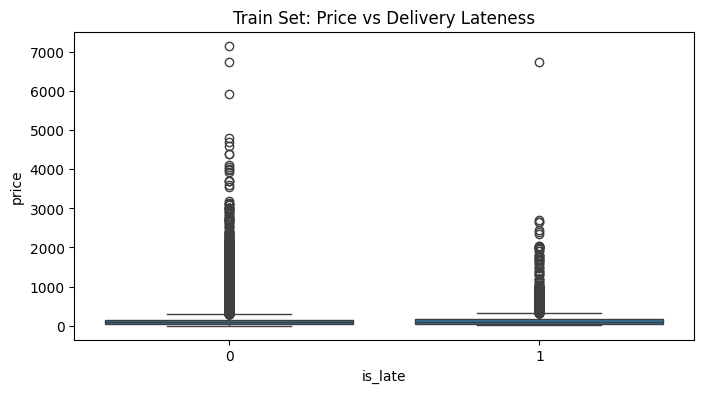

EDA charts generated and saved successfully in artifacts!


In [2]:
os.makedirs('artifacts', exist_ok=True)

plt.figure(figsize=(6, 4))
sns.countplot(x='is_late', data=train_df)
plt.title('Train Set: Delivery Status Distribution (0: On-time, 1: Late)')
plt.savefig('artifacts/eda_train_class_distribution.png')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='is_late', y='price', data=train_df)
plt.title('Train Set: Price vs Delivery Lateness')
plt.savefig('artifacts/eda_price_vs_late.png')
plt.show()

print("EDA charts generated and saved successfully in artifacts!")

C:\Users\User\AppData\Local\Temp\ipykernel_19712\265914152.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df['order_purchase_timestamp'] = pd.to_datetime(train_df['order_purchase_timestamp'])



--- Late Orders Count by Purchase Day of Week ---
purchase_day_of_week
Monday       988
Tuesday      929
Wednesday    823
Friday       818
Thursday     768
Sunday       589
Saturday     564
Name: count, dtype: int64


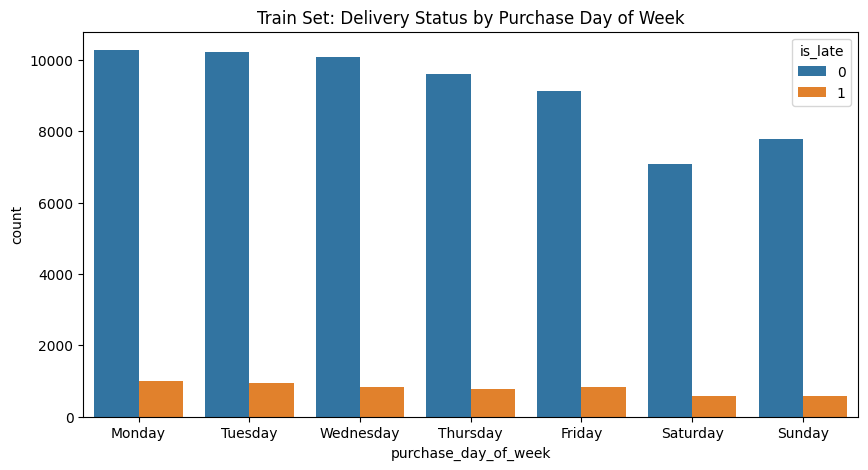

Date and time EDA analysis completed and chart saved!


In [3]:
train_df['order_purchase_timestamp'] = pd.to_datetime(train_df['order_purchase_timestamp'])
train_df['order_estimated_delivery_date'] = pd.to_datetime(train_df['order_estimated_delivery_date'])
train_df['order_delivered_customer_date'] = pd.to_datetime(train_df['order_delivered_customer_date'])

train_df['purchase_day_of_week'] = train_df['order_purchase_timestamp'].dt.day_name()

train_df['delivery_time_days'] = (train_df['order_delivered_customer_date'] - train_df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

print("\n--- Late Orders Count by Purchase Day of Week ---")
print(train_df[train_df['is_late'] == 1]['purchase_day_of_week'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(x='purchase_day_of_week', hue='is_late', data=train_df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Train Set: Delivery Status by Purchase Day of Week')
plt.savefig('artifacts/eda_delivery_by_day.png')
plt.show()

print("Date and time EDA analysis completed and chart saved!")

In [4]:
print("\n--- Customer States Distribution ---")
print(train_df['customer_state'].value_counts().head(5))

print("\n--- EDA Findings Summary ---")
print("- Data has a severe class imbalance (mostly on-time deliveries).")
print("- Missing values identified in date and payment columns.")
print("- Mondays and Tuesdays experience higher delivery pressure.")
print("- Customer states are concentrated in specific regions (e.g., SP, RJ, MG).")


--- Customer States Distribution ---
customer_state
SP    29167
RJ     8939
MG     8190
RS     3870
PR     3514
Name: count, dtype: int64

--- EDA Findings Summary ---
- Data has a severe class imbalance (mostly on-time deliveries).
- Missing values identified in date and payment columns.
- Mondays and Tuesdays experience higher delivery pressure.
- Customer states are concentrated in specific regions (e.g., SP, RJ, MG).
